In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Modeling libraries imported successfully!")

Modeling libraries imported successfully!


In [2]:
# Load the committed offline Titanic dataset
df_model = pd.read_csv("titanic.csv")
print("Dataset loaded successfully!")
print("Shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Dataset loaded successfully!
Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [3]:
# ==========================================
# PREPARE DATA FOR MODELING
# ==========================================

# Remove rows with missing embarked values,
# matching the cleaning decision from EDA.
df_model = df_model.dropna(subset=["embarked"]).copy()
# Features and target
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
X = df_model[features]
y = df_model["survived"]
print("Modeling dataset shape:", df_model.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)
print("\nMissing values:")
print(X.isnull().sum())

Modeling dataset shape: (889, 15)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target:
survived

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      0
dtype: int64


In [4]:
# ==========================================
# STRATIFIED TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\n========== TRAINING CLASS BALANCE ==========")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("\n========== TEST CLASS BALANCE ==========")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set shape: (711, 7)
Test set shape: (178, 7)

========== TRAINING CLASS BALANCE ==========
survived
0    439
1    272
Name: count, dtype: int64
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

========== TEST CLASS BALANCE ==========
survived
0    110
1     68
Name: count, dtype: int64
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [5]:
# ==========================================
# PREPROCESSING PIPELINE
# ==========================================
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]
categorical_features = [
    "sex",
    "embarked"
]
# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
# Combine both
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [6]:
# ==========================================
# LOGISTIC REGRESSION
# ==========================================
from sklearn.linear_model import LogisticRegression
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
# Train only on training data
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [7]:
# ==========================================
# DECISION TREE
# ==========================================
from sklearn.tree import DecisionTreeClassifier
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
# Train only on training data
tree_pipeline.fit(X_train, y_train)
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [8]:
# ==========================================
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])
# Train only on training data
rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
# ==========================================
# MODEL EVALUATION
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline
}
results = []
for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    # Probability of survival
    y_prob = model.predict_proba(X_test)[:, 1]
    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
comparison_df = pd.DataFrame(results)
print("========== MODEL COMPARISON ==========")
print(comparison_df.round(4))


========== MODEL COMPARISON ==========
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912    0.7344   0.8610
1        Decision Tree    0.7697     0.6901  0.7206    0.7050   0.7541
2        Random Forest    0.8202     0.7812  0.7353    0.7576   0.8179



Logistic Regression
[[97 13]
 [21 47]]


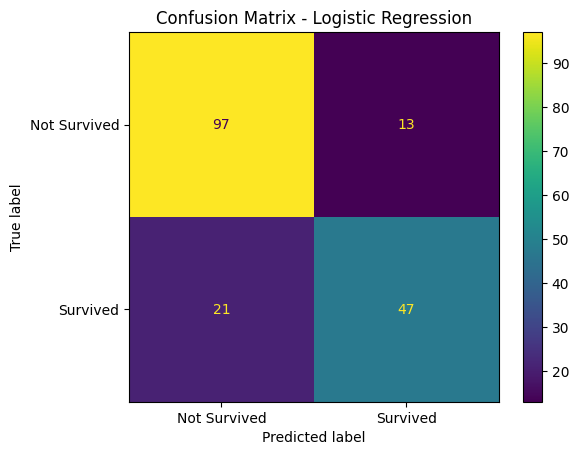


Decision Tree
[[88 22]
 [19 49]]


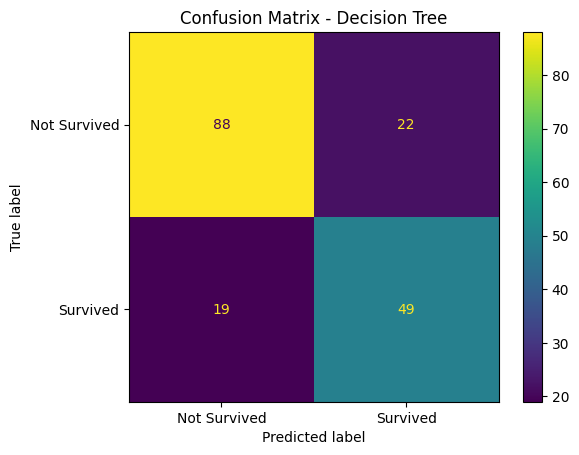


Random Forest
[[96 14]
 [18 50]]


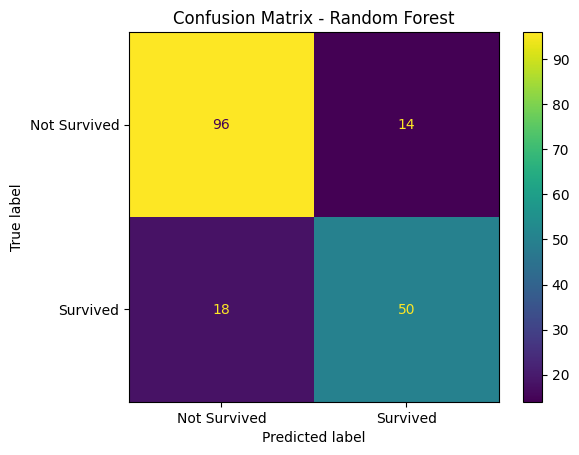

In [10]:
# ==========================================
# CONFUSION MATRICES
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name}")
    print(cm)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [11]:
# ==========================================
# CLASS BALANCE
# ==========================================
class_counts = y_train.value_counts().sort_index()
class_percentages = y_train.value_counts(normalize=True).sort_index() * 100
class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})
class_balance.index = ["Not Survived (0)", "Survived (1)"]
print("========== TRAINING CLASS BALANCE ==========")
print(class_balance.round(2))

========== TRAINING CLASS BALANCE ==========
                  Count  Percentage
Not Survived (0)    439       61.74
Survived (1)        272       38.26


In [12]:
# ==========================================
# LOGISTIC REGRESSION - BALANCED WEIGHTS
# ==========================================
balanced_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])
balanced_logistic_pipeline.fit(X_train, y_train)
# Predictions
y_pred_balanced = balanced_logistic_pipeline.predict(X_test)
# Metrics
balanced_results = {
    "Model": "Logistic Regression - Balanced",
    "Precision": precision_score(y_test, y_pred_balanced),
    "Recall": recall_score(y_test, y_pred_balanced),
    "F1 Score": f1_score(y_test, y_pred_balanced)
}
print("========== BALANCED LOGISTIC REGRESSION ==========")
print(pd.DataFrame([balanced_results]).round(4))

========== BALANCED LOGISTIC REGRESSION ==========
                            Model  Precision  Recall  F1 Score
0  Logistic Regression - Balanced     0.7183    0.75    0.7338


In [13]:
# ==========================================
# SMOTE - TRAINING DATA ONLY
# ==========================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
smote_logistic_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])
# SMOTE is applied only during fitting on X_train
smote_logistic_pipeline.fit(X_train, y_train)
# Predict on the untouched test set
y_pred_smote = smote_logistic_pipeline.predict(X_test)
smote_results = {
    "Model": "Logistic Regression - SMOTE",
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1 Score": f1_score(y_test, y_pred_smote)
}
print("========== SMOTE LOGISTIC REGRESSION ==========")
print(pd.DataFrame([smote_results]).round(4))

========== SMOTE LOGISTIC REGRESSION ==========
                         Model  Precision  Recall  F1 Score
0  Logistic Regression - SMOTE     0.7353  0.7353    0.7353


In [14]:
# ==========================================
# IMBALANCE HANDLING COMPARISON
# ==========================================
imbalance_comparison = pd.DataFrame([
    {
        "Method": "Baseline Logistic Regression",
        "Precision": precision_score(y_test, logistic_pipeline.predict(X_test)),
        "Recall": recall_score(y_test, logistic_pipeline.predict(X_test)),
        "F1 Score": f1_score(y_test, logistic_pipeline.predict(X_test))
    },
    {
        "Method": "Class Weight = Balanced",
        "Precision": balanced_results["Precision"],
        "Recall": balanced_results["Recall"],
        "F1 Score": balanced_results["F1 Score"]
    },
    {
        "Method": "SMOTE",
        "Precision": smote_results["Precision"],
        "Recall": smote_results["Recall"],
        "F1 Score": smote_results["F1 Score"]
    }
])
print("========== IMBALANCE HANDLING COMPARISON ==========")
print(imbalance_comparison.round(4))

========== IMBALANCE HANDLING COMPARISON ==========
                         Method  Precision  Recall  F1 Score
0  Baseline Logistic Regression     0.7833  0.6912    0.7344
1       Class Weight = Balanced     0.7183  0.7500    0.7338
2                         SMOTE     0.7353  0.7353    0.7353


In [15]:
# ==========================================
# RANDOM FOREST - GRID SEARCH
# ==========================================
from sklearn.model_selection import GridSearchCV
rf_grid_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}
grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("========== GRID SEARCH COMPLETED ==========")
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

========== GRID SEARCH COMPLETED ==========
Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7408


In [16]:
# ==========================================
# BEST RANDOM FOREST - OOB SCORE
# ==========================================
best_rf_pipeline = grid_search.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["classifier"]
print("========== BEST RANDOM FOREST ==========")
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))
print("\nOOB Score:")
print(round(best_rf_model.oob_score_, 4))

========== BEST RANDOM FOREST ==========
Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7408

OOB Score:
0.8214


In [17]:
# ==========================================
# FARE REGRESSION - DATA PREPARATION
# ==========================================
regression_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]
X_reg = df_model[regression_features]
y_reg = df_model["fare"]
print("========== FARE REGRESSION DATA ==========")
print("Features:")
print(X_reg.columns.tolist())
print("\nTarget:")
print(y_reg.name)
print("\nShape:", X_reg.shape)
print("\nMissing values:")
print(X_reg.isnull().sum())

========== FARE REGRESSION DATA ==========
Features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Target:
fare

Shape: (889, 7)

Missing values:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
embarked      0
dtype: int64


In [18]:
# ==========================================
# REGRESSION TRAIN/TEST SPLIT
# ==========================================
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)
print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape:", X_reg_test.shape)

Regression training shape: (711, 7)
Regression testing shape: (178, 7)


In [19]:
# ==========================================
# MULTIVARIATE LINEAR REGRESSION
# ==========================================
from sklearn.linear_model import LinearRegression
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]
reg_categorical_features = [
    "sex",
    "embarked"
]
reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features)
])
linear_regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])
# Train only on regression training data
linear_regression_pipeline.fit(X_reg_train, y_reg_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
# ==========================================
# REGRESSION EVALUATION
# ==========================================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Predictions on untouched test data
y_reg_pred = linear_regression_pipeline.predict(X_reg_test)
# Calculate metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)
# Number of observations and predictors
n = len(y_reg_test)
# Get number of transformed predictors after preprocessing
transformed_feature_count = (
    linear_regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
    .shape[0]
)
p = transformed_feature_count
# Adjusted R²
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("========== REGRESSION METRICS ==========")
print(f"MAE:          {mae:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"R²:           {r2:.4f}")
print(f"Adjusted R²:  {adjusted_r2:.4f}")
print(f"\nTest samples (n): {n}")
print(f"Predictors (p):   {p}")

========== REGRESSION METRICS ==========
MAE:          21.0998
RMSE:         41.7022
R²:           0.3482
Adjusted R²:  0.3091

Test samples (n): 178
Predictors (p):   10


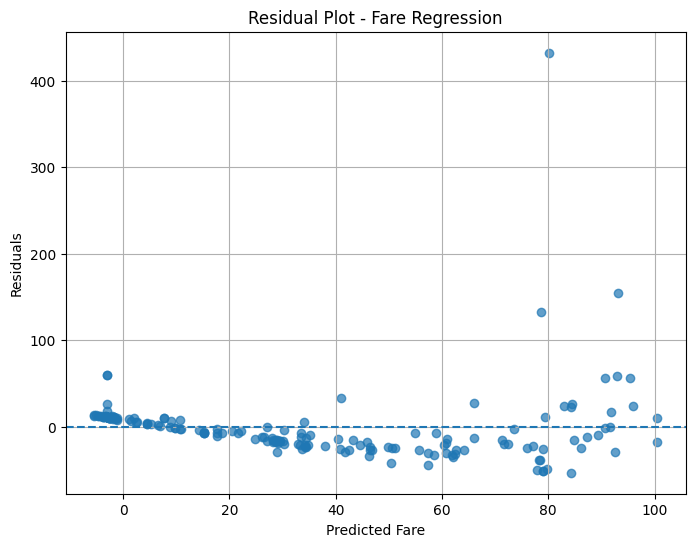

Residual plot saved to charts/fare_regression_residuals.png


In [21]:
# ==========================================
# SAVE RESIDUAL PLOT
# ==========================================
import os
import matplotlib.pyplot as plt
os.makedirs("charts", exist_ok=True)
residuals = y_reg_test - y_reg_pred
plt.figure(figsize=(8, 6))
plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.7
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")
plt.grid(True)
plt.savefig(
    "charts/fare_regression_residuals.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Residual plot saved to charts/fare_regression_residuals.png")

In [22]:
# ==========================================
# TUNED RANDOM FOREST - TEST SET EVALUATION
# ==========================================
best_rf_pred = best_rf_pipeline.predict(X_test)
best_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
tuned_rf_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, best_rf_pred),
    "Precision": precision_score(y_test, best_rf_pred),
    "Recall": recall_score(y_test, best_rf_pred),
    "F1 Score": f1_score(y_test, best_rf_pred),
    "ROC-AUC": roc_auc_score(y_test, best_rf_prob)
}
print("========== TUNED RANDOM FOREST ==========")
print(pd.DataFrame([tuned_rf_results]).round(4))

========== TUNED RANDOM FOREST ==========
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Tuned Random Forest    0.8315     0.8654  0.6618      0.75   0.8389


In [23]:
# ==========================================
# FINAL CLASSIFIER COMPARISON
# ==========================================
final_classifier_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": comparison_df.loc[
            comparison_df["Model"] == "Logistic Regression", "Accuracy"
        ].iloc[0],
        "Precision": comparison_df.loc[
            comparison_df["Model"] == "Logistic Regression", "Precision"
        ].iloc[0],
        "Recall": comparison_df.loc[
            comparison_df["Model"] == "Logistic Regression", "Recall"
        ].iloc[0],
        "F1 Score": comparison_df.loc[
            comparison_df["Model"] == "Logistic Regression", "F1 Score"
        ].iloc[0],
        "ROC-AUC": comparison_df.loc[
            comparison_df["Model"] == "Logistic Regression", "ROC-AUC"
        ].iloc[0]
    },
    {
        "Model": "Decision Tree",
        "Accuracy": comparison_df.loc[
            comparison_df["Model"] == "Decision Tree", "Accuracy"
        ].iloc[0],
        "Precision": comparison_df.loc[
            comparison_df["Model"] == "Decision Tree", "Precision"
        ].iloc[0],
        "Recall": comparison_df.loc[
            comparison_df["Model"] == "Decision Tree", "Recall"
        ].iloc[0],
        "F1 Score": comparison_df.loc[
            comparison_df["Model"] == "Decision Tree", "F1 Score"
        ].iloc[0],
        "ROC-AUC": comparison_df.loc[
            comparison_df["Model"] == "Decision Tree", "ROC-AUC"
        ].iloc[0]
    },
    {
        "Model": "Random Forest",
        "Accuracy": comparison_df.loc[
            comparison_df["Model"] == "Random Forest", "Accuracy"
        ].iloc[0],
        "Precision": comparison_df.loc[
            comparison_df["Model"] == "Random Forest", "Precision"
        ].iloc[0],
        "Recall": comparison_df.loc[
            comparison_df["Model"] == "Random Forest", "Recall"
        ].iloc[0],
        "F1 Score": comparison_df.loc[
            comparison_df["Model"] == "Random Forest", "F1 Score"
        ].iloc[0],
        "ROC-AUC": comparison_df.loc[
            comparison_df["Model"] == "Random Forest", "ROC-AUC"
        ].iloc[0]
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_rf_results["Accuracy"],
        "Precision": tuned_rf_results["Precision"],
        "Recall": tuned_rf_results["Recall"],
        "F1 Score": tuned_rf_results["F1 Score"],
        "ROC-AUC": tuned_rf_results["ROC-AUC"]
    }
])
print("========== FINAL CLASSIFIER COMPARISON ==========")
print(final_classifier_results.round(4))

========== FINAL CLASSIFIER COMPARISON ==========
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912    0.7344   0.8610
1        Decision Tree    0.7697     0.6901  0.7206    0.7050   0.7541
2        Random Forest    0.8202     0.7812  0.7353    0.7576   0.8179
3  Tuned Random Forest    0.8315     0.8654  0.6618    0.7500   0.8389


In [24]:
# ==========================================
# FINAL REGRESSION METRICS TABLE
# ==========================================

final_regression_results = pd.DataFrame([
    {
        "Model": "Multivariate Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])
print("========== FINAL REGRESSION RESULTS ==========")
print(final_regression_results.round(4))

========== FINAL REGRESSION RESULTS ==========
                            Model      MAE     RMSE      R²  Adjusted R²
0  Multivariate Linear Regression  21.0998  41.7022  0.3482       0.3091


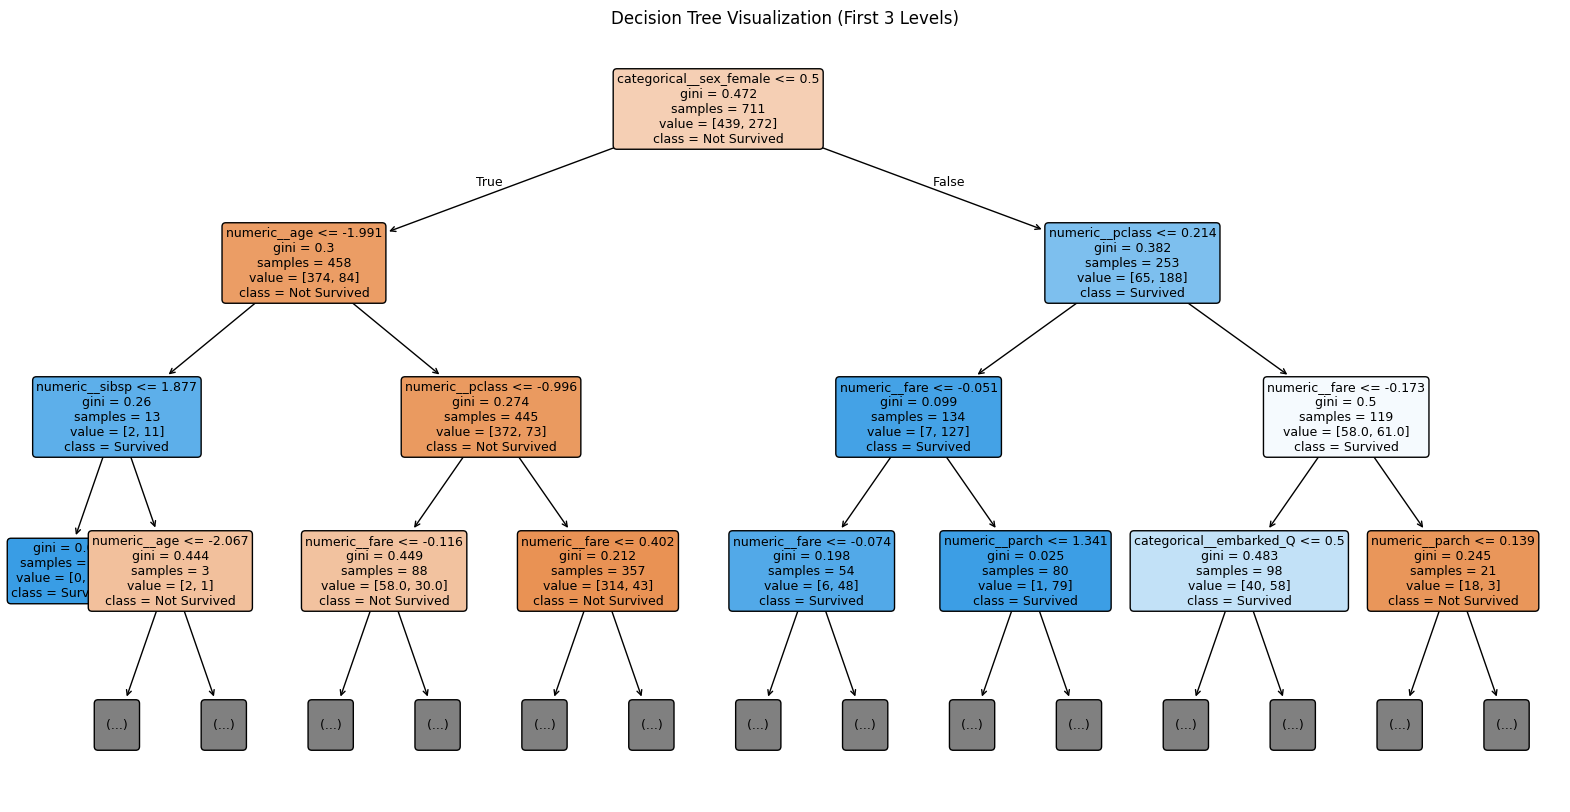

Decision Tree chart saved to charts/decision_tree.png


In [25]:
# ==========================================
# SAVE DECISION TREE VISUALIZATION
# ==========================================
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
tree_feature_names = (
    tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get the trained tree model
tree_model = tree_pipeline.named_steps["classifier"]
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.savefig(
    "charts/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Decision Tree chart saved to charts/decision_tree.png")

In [26]:
# ==========================================
# SAVE FINAL FITTED PIPELINE
# ==========================================
import joblib
# Save the complete fitted pipeline
joblib.dump(
    best_rf_pipeline,
    "best_pipeline.joblib"
)
print("Best pipeline saved successfully!")
print("File: analytics/best_pipeline.joblib")

Best pipeline saved successfully!
File: analytics/best_pipeline.joblib


In [27]:
# ==========================================
# RELOAD SAVED PIPELINE AND TEST
# ==========================================
# Load the saved pipeline
loaded_pipeline = joblib.load("best_pipeline.joblib")
# Use raw test rows - no manual preprocessing
raw_test_sample = X_test.head(5)
# Make predictions
loaded_predictions = loaded_pipeline.predict(raw_test_sample)
print("========== RELOADED PIPELINE TEST ==========")
print("Raw input shape:", raw_test_sample.shape)
print("Predictions:", loaded_predictions)
print("Pipeline reload and prediction successful!")

========== RELOADED PIPELINE TEST ==========
Raw input shape: (5, 7)
Predictions: [0 0 0 0 0]
Pipeline reload and prediction successful!


In [28]:
# ==========================================
# SAVE MODEL COMPARISON RESULTS
# ==========================================
final_classifier_results.to_csv(
    "classifier_comparison.csv",
    index=False
)
final_regression_results.to_csv(
    "regression_results.csv",
    index=False
)
imbalance_comparison.to_csv(
    "imbalance_comparison.csv",
    index=False
)
print("Result tables saved successfully!")
print("- classifier_comparison.csv")
print("- regression_results.csv")
print("- imbalance_comparison.csv")

Result tables saved successfully!
- classifier_comparison.csv
- regression_results.csv
- imbalance_comparison.csv


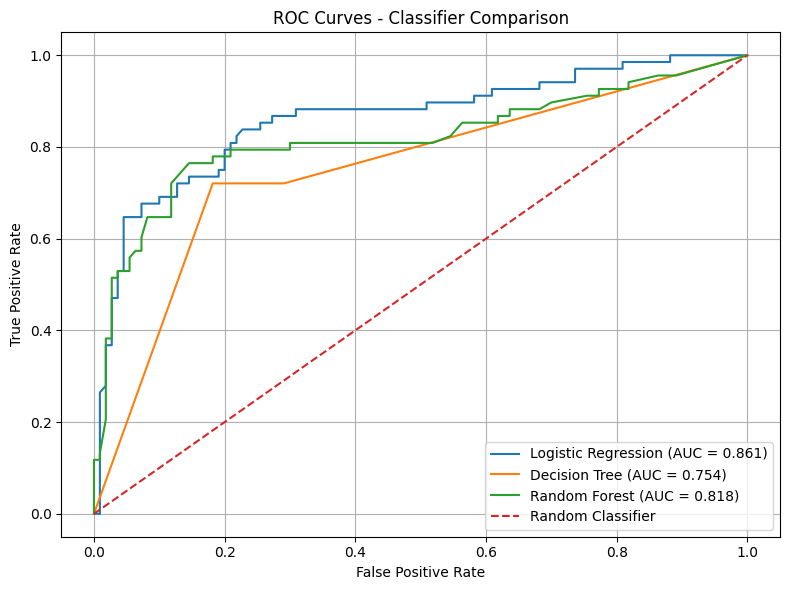

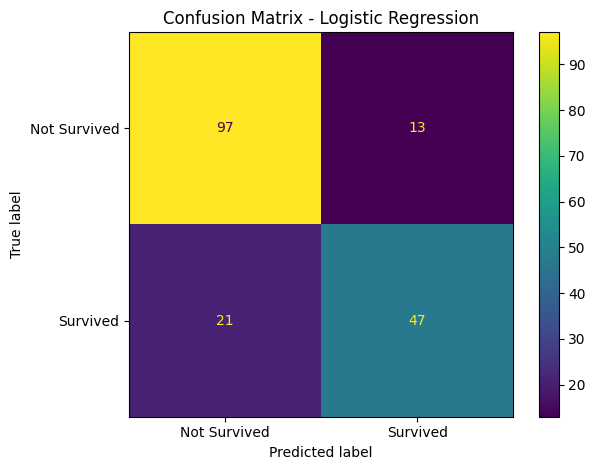

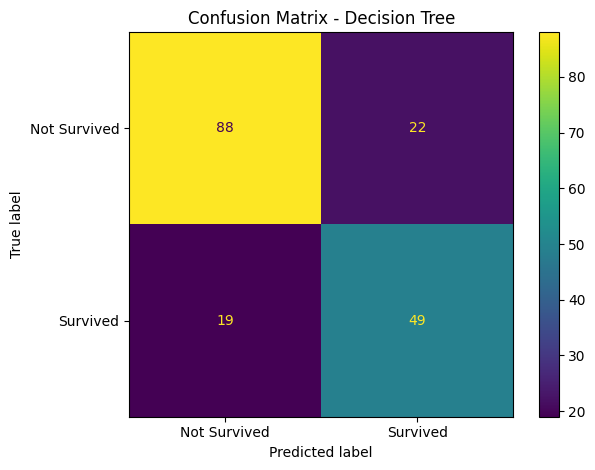

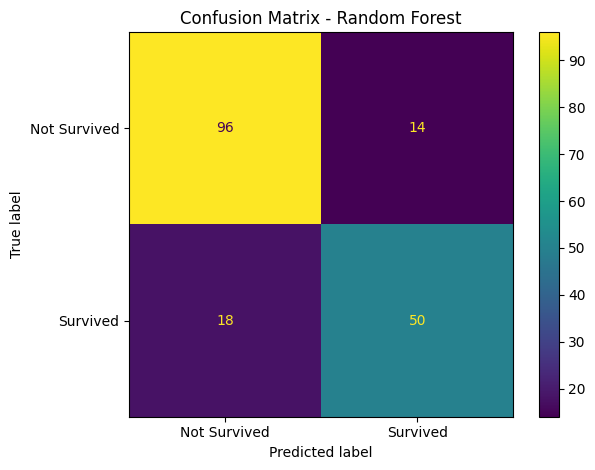

All modeling charts saved successfully!


In [29]:
import os
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)
os.makedirs("charts", exist_ok=True)
# ROC Curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Classifier Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
# Confusion Matrices
for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "")
        + "_confusion_matrix.png"
    )
    plt.savefig(
        f"charts/{filename}",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
print("All modeling charts saved successfully!")

## Modeling Findings and Conclusions

### Why stratified train/test splitting was used

The target variable is `survived`, and the two classes are not equally distributed. I used a stratified train/test split so that the proportion of survivors and non-survivors remains similar in both the training and test sets. This makes the model evaluation more representative and avoids an unusually different class distribution between the two sets.

### Preprocessing and leakage prevention

All imputation, encoding and scaling steps are included inside the model pipelines. The pipelines are fitted only using the training data. The test data is passed through the already-fitted preprocessing steps without fitting or refitting them. This prevents information from the test set from leaking into model training.

### Classifier comparison

Logistic Regression achieved an accuracy of 0.8090 and F1 score of 0.7344. Decision Tree achieved an accuracy of 0.7697 and F1 score of 0.7050. Random Forest achieved an accuracy of 0.8202 and F1 score of 0.7576.

The tuned Random Forest achieved an accuracy of 0.8315, precision of 0.8654, recall of 0.6618, F1 score of 0.7500 and ROC-AUC of 0.8389. It improved accuracy and precision, but its recall was lower than the untuned Random Forest.

### Class imbalance handling

The baseline Logistic Regression had precision 0.7833, recall 0.6912 and F1 score 0.7344.

Using `class_weight="balanced"` increased recall to 0.7500, but precision decreased to 0.7183 and F1 was 0.7338.

SMOTE produced precision 0.7353, recall 0.7353 and F1 score 0.7353. Compared with the baseline, SMOTE gave a more balanced precision and recall with a similar F1 score.

This experiment shows that handling class imbalance changes the precision-recall trade-off, so the best method depends on which metric is more important for the application.

### Random Forest tuning

GridSearchCV selected:

* `n_estimators = 200`
* `max_depth = 5`
* `max_features = "sqrt"`

The best cross-validation F1 score was 0.7408 and the OOB score was 0.8214.

The tuned model improved test accuracy compared with the untuned Random Forest, while the test F1 score was slightly lower.

### Fare regression

The Multivariate Linear Regression model achieved:

* MAE = 21.0998
* RMSE = 41.7022
* R² = 0.3482
* Adjusted R² = 0.3091

The R² value indicates that the model explains a limited portion of the variation in fare. The difference between MAE and RMSE also shows that some prediction errors are relatively large.

### Heteroscedasticity conclusion

The residual plot shows that the spread of residuals is not constant across the predicted fare values, with larger variation at higher predicted fares. This suggests the presence of heteroscedasticity. Therefore, the constant-variance assumption of ordinary linear regression is not fully satisfied for this regression task.

### Final recommendation

For this project, I would use the tuned Random Forest when overall accuracy and precision are the main priorities. It achieved the highest test accuracy and precision among the compared classifiers. However, its recall was lower than the untuned Random Forest, so the untuned Random Forest would also be reasonable when identifying as many survivors as possible is more important.

The classifier metrics and regression metrics are kept in separate tables because they measure different types of prediction problems and should not be compared on one common scale.
